In [1]:
import os
from matplotlib import pyplot as plt
import tensorflow as tf 
import tensorflow_io as tfio
#os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
#unset CUDA_VISIBLE_DEVICES
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

In [2]:
import pandas as pd
csv_file_path = os.path.join('data', 'Respiratory_Dataset', 'patient_diagnosis.csv')
df = pd.read_csv(csv_file_path)

copd_id = []
no_copd_id = []
for index, row in df.iterrows():
    if row['Label'] == "COPD":
        copd_id.append(str(row['ID']))
    elif row['Label'] == "Healthy":
        no_copd_id.append(str(row['ID']))

print(copd_id, len(copd_id))
print(no_copd_id, len(no_copd_id))

['104', '106', '107', '109', '110', '112', '113', '114', '117', '118', '120', '124', '128', '130', '132', '133', '134', '138', '139', '141', '142', '145', '146', '147', '151', '154', '155', '156', '157', '158', '160', '162', '163', '166', '170', '172', '174', '175', '176', '177', '178', '180', '181', '185', '186', '189', '192', '193', '195', '198', '199', '200', '203', '204', '205', '207', '211', '212', '213', '218', '220', '221', '222', '223'] 64
['102', '121', '123', '125', '126', '127', '136', '143', '144', '152', '153', '159', '171', '179', '182', '183', '184', '187', '194', '202', '208', '209', '214', '217', '224', '225'] 26


In [3]:
import glob
import soundfile
data_path = os.path.join('data', 'Respiratory_Dataset', 'selected_data', '*.wav')
all_data_path_list = glob.glob(data_path)


# # convert from 24k to 16k wav
# for p in external_no_copd_path:
#     data, samplerate = soundfile.read(p)
#     soundfile.write(p.replace('normal', '16k_normal'), data, samplerate, subtype='PCM_16')
                    
copd_path = []
no_copd_path = []
for data_path in all_data_path_list:
    case_id = data_path.split(os.path.sep)[-1].split("_")[0]
    if case_id in copd_id:
        copd_path.append(data_path)
    elif case_id in no_copd_id:
        no_copd_path.append(data_path)
# print(copd_path)
external_no_copd_path = glob.glob(os.path.join("data", 'Respiratory_Dataset', '16k_normal', "*.wav"))
# print(external_no_copd_path)
copd_path = copd_path[:79]
no_copd_path = no_copd_path + external_no_copd_path

In [4]:
print(len(copd_path))
print(len(no_copd_path))

79
79


In [5]:
def load_wav_16k_mono(filename):
    # Load encoded wav file
    file_contents = tf.io.read_file(filename)
    # Decode wav (tensors by channels) 
    wav, sample_rate = tf.audio.decode_wav(file_contents, desired_channels=1)
    # Removes trailing axis
    wav = tf.squeeze(wav, axis=-1)
    sample_rate = tf.cast(sample_rate, dtype=tf.int64)
    # Goes from 44100Hz to 16000hz - amplitude of the audio signal
    wav = tfio.audio.resample(wav, rate_in=sample_rate, rate_out=16000)
    return wav

In [6]:
wave = load_wav_16k_mono(copd_path[0])
nwave = load_wav_16k_mono(no_copd_path[0])

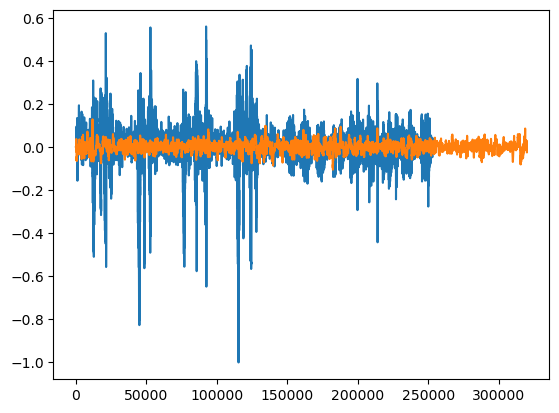

In [7]:
plt.plot(wave)
plt.plot(nwave)
plt.show()

In [8]:
pos = tf.data.Dataset.list_files(copd_path)
neg = tf.data.Dataset.list_files(no_copd_path)

In [9]:
positives = tf.data.Dataset.zip((pos, tf.data.Dataset.from_tensor_slices(tf.ones(len(pos)))))
negatives = tf.data.Dataset.zip((neg, tf.data.Dataset.from_tensor_slices(tf.zeros(len(neg)))))
data = positives.concatenate(negatives)


In [10]:
def preprocess(file_path, label): 
    wav = load_wav_16k_mono(file_path)
    wav = wav[:48000]
    zero_padding = tf.zeros([48000] - tf.shape(wav), dtype=tf.float32)
    wav = tf.concat([zero_padding, wav],0)
    spectrogram = tf.signal.stft(wav, frame_length=320, frame_step=32)
    spectrogram = tf.abs(spectrogram)
    spectrogram = tf.expand_dims(spectrogram, axis=2)
    return spectrogram, label

In [11]:
data = data.map(preprocess)
data = data.cache()
data = data.shuffle(buffer_size=1000)
data = data.batch(4)
data = data.prefetch(8)

In [12]:
train = data.take(20)
test = data.skip(20).take(19)

In [13]:
# print(train.as_numpy_iterator().next()[0].shape)
# print(test.as_numpy_iterator().next()[0].shape)

In [14]:
samples, labels = train.as_numpy_iterator().next()
samples.shape

(4, 1491, 257, 1)

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten

In [16]:
model = Sequential()
model.add(Conv2D(16, (3,3), activation='relu', input_shape=(1491, 257,1)))
model.add(Conv2D(16, (3,3), activation='relu'))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile('Adam', loss='BinaryCrossentropy', metrics=[tf.keras.metrics.Recall(),tf.keras.metrics.Precision()])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 1489, 255, 16)     160       
                                                                 
 conv2d_1 (Conv2D)           (None, 1487, 253, 16)     2320      
                                                                 
 flatten (Flatten)           (None, 6019376)           0         
                                                                 
 dense (Dense)               (None, 128)               770480256 
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                                 
Total params: 770,482,865
Trainable params: 770,482,865
Non-trainable params: 0
_________________________________________________________________


In [17]:
hist = model.fit(train, epochs=4, validation_data=test)


Epoch 1/4
20/20 [==============================] - 63s 3s/step - loss: 13.9558 - recall: 0.8250 - precision: 0.6226 - val_loss: 5.5252 - val_recall: 0.6000 - val_precision: 0.8750
Epoch 2/4
20/20 [==============================] - 62s 3s/step - loss: 4.2373 - recall: 0.7750 - precision: 0.5254 - val_loss: 1.3528 - val_recall: 0.9429 - val_precision: 0.5156
Epoch 3/4
20/20 [==============================] - 63s 3s/step - loss: 0.9243 - recall: 0.9268 - precision: 0.6441 - val_loss: 0.2412 - val_recall: 0.9524 - val_precision: 0.9524
Epoch 4/4
20/20 [==============================] - 61s 3s/step - loss: 0.1989 - recall: 0.9778 - precision: 1.0000 - val_loss: 0.1549 - val_recall: 0.9767 - val_precision: 1.0000


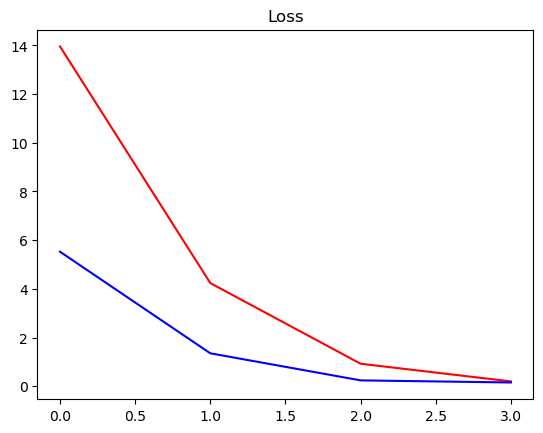

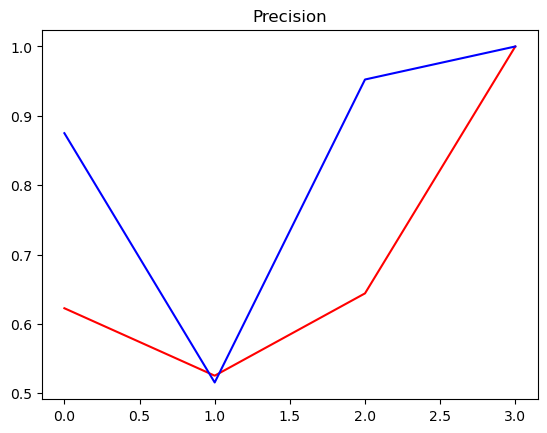

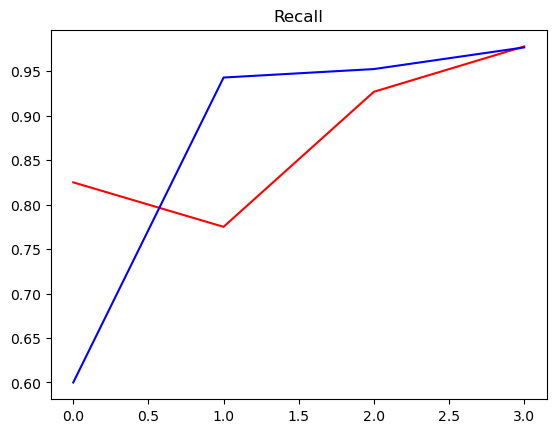

In [18]:
plt.title('Loss')
plt.plot(hist.history['loss'], 'r')
plt.plot(hist.history['val_loss'], 'b')
plt.show()
plt.title('Precision')
plt.plot(hist.history['precision'], 'r')
plt.plot(hist.history['val_precision'], 'b')
plt.show()
plt.title('Recall')
plt.plot(hist.history['recall'], 'r')
plt.plot(hist.history['val_recall'], 'b')
plt.show()

In [19]:
listy = []
listyhat=[]
for X_test, y_test in test.as_numpy_iterator():
    for a in y_test:
        listy.append(a.astype(int))
    conf = model.predict(X_test)
    yhat = [1 if prediction > 0.5 else 0 for prediction in conf]
    for b in yhat:
        listyhat.append(b)
    for c, pred, true in zip(conf, yhat, y_test):
        print("confidence:", c, "pred:", pred, "true:", true)
print(listy)
print(listyhat)

1/1 [==============================] - 0s 261ms/step
confidence: [0.9999996] pred: 1 true: 1.0
confidence: [0.45012686] pred: 0 true: 0.0
confidence: [0.99847895] pred: 1 true: 1.0
confidence: [0.04147297] pred: 0 true: 0.0
1/1 [==============================] - 0s 213ms/step
confidence: [0.04147297] pred: 0 true: 0.0
confidence: [0.98635393] pred: 1 true: 1.0
confidence: [0.03169269] pred: 0 true: 0.0
confidence: [0.291623] pred: 0 true: 0.0
1/1 [==============================] - 0s 215ms/step
confidence: [1.2135123e-09] pred: 0 true: 0.0
confidence: [0.99780715] pred: 1 true: 1.0
confidence: [1.] pred: 1 true: 1.0
confidence: [0.9916043] pred: 1 true: 1.0
1/1 [==============================] - 0s 218ms/step
confidence: [0.1874589] pred: 0 true: 0.0
confidence: [0.98871213] pred: 1 true: 1.0
confidence: [0.43397745] pred: 0 true: 0.0
confidence: [1.] pred: 1 true: 1.0
1/1 [==============================] - 0s 217ms/step
confidence: [0.40782878] pred: 0 true: 0.0
confidence: [0.4258121

In [20]:
from sklearn.metrics import confusion_matrix
tn, fp, fn, tp = confusion_matrix(listy, listyhat).ravel()
print(tn, fp, fn, tp)

accuracy = (tp+tn)/(tn+fp+fn+tp)
precision = (tp)/(tp+fp)
recall = (tp)/(tp+fn)
F1 = (2*tp)/(2*tp+fp+fn)
print("accuracy:", accuracy, "precision:", precision, "recall:", recall, "F1 score:", F1)

40 0 1 35
accuracy: 0.9868421052631579 precision: 1.0 recall: 0.9722222222222222 F1 score: 0.9859154929577465


In [21]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


In [22]:
def test_preprocess(file_path): 
    wav = load_wav_16k_mono(file_path)
    wav = wav[:48000]
    zero_padding = tf.zeros([48000] - tf.shape(wav), dtype=tf.float32)
    wav = tf.concat([zero_padding, wav],0)
    spectrogram = tf.signal.stft(wav, frame_length=320, frame_step=32)
    spectrogram = tf.abs(spectrogram)
    spectrogram = tf.expand_dims(spectrogram, axis=2)
    return spectrogram

In [23]:
external_test_data =[]
external_test_data.extend(glob.glob(os.path.join('data', 'Audio_Files', '*N,N,*.wav'))) 
external_test_data.extend(glob.glob(os.path.join('data', 'Audio_Files', '*COPD*.wav')))  
external_test_data.extend(glob.glob(os.path.join('data', 'Audio_Files', '*copd*.wav')))
print(len(external_test_data))
external_test_label = []
for d in external_test_data:
    if "N,N," in d:
        external_test_label.append(0)
    elif ("COPD" in d) or ("copd" in d):
        external_test_label.append(1)

171


In [24]:
data = tf.data.Dataset.list_files(external_test_data)
data = data.map(test_preprocess)
data = data.batch(1)
test_result = []
for idx, x_test in enumerate(data.as_numpy_iterator()):
    pred_result = model.predict(x_test)[0]
    test_result.append(int(pred_result[0]>0.5))
    if pred_result[0]>0.5:
        check = 'May be COPD'
    else:
        check = 'You are healthy'
    print(external_test_data[idx].split(os.path.sep)[-1], pred_result, int(pred_result[0]>0.5), external_test_label[idx],check)

1/1 [==============================] - 0s 262ms/step
BP100_N,N,P R M,70,F.wav [0.64926803] 1 0 May be COPD
1/1 [==============================] - 0s 327ms/step
BP102_N,N,P L L,41,M.wav [0.6723559] 1 0 May be COPD
1/1 [==============================] - 0s 263ms/step
BP103_N,N,P R U,81,F.wav [0.12989753] 0 0 You are healthy
1/1 [==============================] - 0s 260ms/step
BP109_N,N,P L M,26,M.wav [0.9961218] 1 0 May be COPD
1/1 [==============================] - 0s 261ms/step
BP112_N,N,P L M,30,M.wav [0.49748093] 0 0 You are healthy
1/1 [==============================] - 0s 265ms/step
BP30_N,N,P R M,18,F.wav [0.56951636] 1 0 May be COPD
1/1 [==============================] - 0s 261ms/step
BP31_N,N,P L M,27,F.wav [0.7726842] 1 0 May be COPD
1/1 [==============================] - 0s 320ms/step
BP32_N,N,A R L,30,M.wav [0.56951636] 1 0 May be COPD
1/1 [==============================] - 0s 264ms/step
BP48_N,N,P L U,31,M.wav [0.6368746] 1 0 May be COPD
1/1 [==============================] 

1/1 [==============================] - 0s 265ms/step
EP30_N,N,P R M,18,F.wav [0.88246304] 1 0 May be COPD
1/1 [==============================] - 0s 264ms/step
EP31_N,N,P L M,27,F.wav [0.66791] 1 0 May be COPD
1/1 [==============================] - 0s 264ms/step
EP32_N,N,A R L,30,M.wav [0.2295329] 0 0 You are healthy
1/1 [==============================] - 0s 258ms/step
EP48_N,N,P L U,31,M.wav [0.82314783] 1 0 May be COPD
1/1 [==============================] - 0s 264ms/step
EP49_N,N,P R M,21,M.wav [0.9473102] 1 0 May be COPD
1/1 [==============================] - 0s 262ms/step
EP50_N,N,P R L ,27,M.wav [0.1437313] 0 0 You are healthy
1/1 [==============================] - 0s 264ms/step
EP51_N,N,P L M,30,M.wav [0.8524377] 1 0 May be COPD
1/1 [==============================] - 0s 265ms/step
EP70_N,N,P L U,52,F.wav [0.23152034] 0 0 You are healthy
1/1 [==============================] - 0s 261ms/step
EP71_N,N,P R U,36,M.wav [0.8837222] 1 0 May be COPD
1/1 [==============================] - 0s

1/1 [==============================] - 0s 263ms/step
BP7_Heart Failure + COPD,I C E W,P L R,65,M.wav [0.8991517] 1 1 May be COPD
1/1 [==============================] - 0s 262ms/step
DP108_COPD,E W,P R L ,63,M.wav [0.5784827] 1 1 May be COPD
1/1 [==============================] - 0s 264ms/step
DP110_COPD,E W,P L L,62,M.wav [0.77714664] 1 1 May be COPD
1/1 [==============================] - 0s 261ms/step
DP111_COPD,E W,P R L ,51,M.wav [0.68466383] 1 1 May be COPD
1/1 [==============================] - 0s 261ms/step
DP17_COPD,E W,A R M,57,M.wav [0.35148317] 0 1 You are healthy
1/1 [==============================] - 0s 268ms/step
DP25_copd,E W,P L L,76,M.wav [0.7383941] 1 1 May be COPD
1/1 [==============================] - 0s 259ms/step
DP57_COPD,E W,P R L ,42,M.wav [0.38165432] 0 1 You are healthy
1/1 [==============================] - 0s 266ms/step
DP5_Heart Failure + COPD,I C E W,P L R ,71,M.wav [0.9473102] 1 1 May be COPD
1/1 [==============================] - 0s 263ms/step
DP61_COPD,

In [25]:
from sklearn.metrics import confusion_matrix
print(test_result)
print(external_test_label)
tn, fp, fn, tp = confusion_matrix(test_result, external_test_label).ravel()
print(tn, fp, fn, tp)


[1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [26]:
accuracy = (tp+tn)/(tn+fp+fn+tp)
precision = (tp)/(tp+fp)
recall = (tp)/(tp+fn)
print("accuracy:", accuracy, "precision:", precision, "recall:", recall)

accuracy: 0.49707602339181284 precision: 0.6666666666666666 recall: 0.4074074074074074
